# Grid Search ligero — Random Forest y LightGBM

Busqueda corta con pocos fits

## 1. Configuración

In [ ]:
from pathlib import Path
import os
import sys

REPO_ROOT = next(path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (path / 'data.dvc').is_file())
PACKAGE_SRC = REPO_ROOT / 'packages' / 'sleep-staging' / 'src'
if str(PACKAGE_SRC) not in sys.path:
    sys.path.insert(0, str(PACKAGE_SRC))

from IPython.display import display
from sklearn.model_selection import ParameterGrid
from sleep_staging import PreprocessingConfig, PreprocessingPipeline
from sleep_staging.datasets import discover_sleep_telemetry_records
from sleep_staging.training import (
    MlflowConfig, compare_evaluations,
    create_lightgbm_classifier, create_random_forest_classifier,
    display_evaluation, grouped_grid_search,
    load_or_build_supervised_dataset, split_by_subject,
)

DATA_DIR = REPO_ROOT / 'data' / 'sleep-telemetry'
DATASET_CACHE_DIR = REPO_ROOT / 'data' / 'processed' / 'supervised'
SEED = 42
VALIDATION_SIZE = 0.20
CV_SPLITS = 3
SEARCH_N_JOBS = 1
MAX_RECORDS = None  # usar 6 para validar el flujo; None usa los 44 registros
MLFLOW = MlflowConfig(
    enabled=True,
    experiment_name='sleep_staging_grid_search_light',
    tracking_uri='sqlite:///mlflow.db', #Este es de forma local, si quieres usar mlflow en la nube, cambia el tracking_uri a tu servidor de mlflow
    log_model=False,
)
PIPELINE = PreprocessingPipeline(PreprocessingConfig())
print(f'Procesadores disponibles: {os.cpu_count()} | procesos de búsqueda: {SEARCH_N_JOBS}')

Procesadores disponibles: 16 | procesos de búsqueda: 1


## 2. Dataset y separación por sujeto

El Grid Search usa únicamente training. El holdout de validación permanece intacto hasta evaluar el mejor modelo.

In [2]:
records = discover_sleep_telemetry_records(DATA_DIR)
records = records if MAX_RECORDS is None else records[:MAX_RECORDS]
dataset = load_or_build_supervised_dataset(records, PIPELINE, DATASET_CACHE_DIR)
split = split_by_subject(dataset, validation_size=VALIDATION_SIZE, random_state=SEED)

print(f'Dataset: {dataset.features.shape[0]} épocas x {dataset.features.shape[1]} features')
print(f'Training: {split.X_train.shape} | sujetos: {len(split.train_subjects)}')
print(f'Validación: {split.X_validation.shape} | sujetos: {len(split.validation_subjects)}')
assert set(split.train_subjects).isdisjoint(split.validation_subjects)
display(dataset.labels.value_counts().rename('épocas').sort_index().to_frame())

Cargando dataset desde caché: E:\PROJECTS\Maestria Inteligencia Artificial\masterIADesarollo\micro-proyecto-grupo-7\data\processed\supervised\2c71b3937c5b
Dataset: 42691 épocas x 486 features
Training: (32762, 486) | sujetos: 17
Validación: (9929, 486) | sujetos: 5


,épocas
stage,
N1,3653
N2,19851
N3,6415
REM,8349
W,4423


## 3. Random Forest — 8 combinaciones

Se fija `n_estimators=300` para controlar el tiempo y se exploran profundidad, regularización por hoja y cantidad de features. Estas decisiones suelen aportar más información que comparar 300 contra 500 árboles en una primera búsqueda.

In [7]:
RF_GRID = {
    'n_estimators': [500],
    'max_depth': [None, 20],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 0.1],
}
rf_candidates = len(list(ParameterGrid(RF_GRID)))
print(f'Random Forest: {rf_candidates} combinaciones × {CV_SPLITS} folds = {rf_candidates * CV_SPLITS} fits')

random_forest = create_random_forest_classifier(random_state=SEED, n_jobs=-1)
rf_search = grouped_grid_search(
    random_forest, RF_GRID, split, model_name='Random Forest optimizado light',
    n_splits=CV_SPLITS, n_jobs=SEARCH_N_JOBS, verbose=10,
    mlflow_config=MLFLOW,
)
print(f'Mejor F1 macro CV: {rf_search.best_cv_score:.4f}')
print(f'Mejores parámetros: {rf_search.best_parameters}')
display(rf_search.cv_results)

Random Forest: 8 combinaciones × 3 folds = 24 fits
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV 1/3; 1/8] START max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=500
[CV 1/3; 1/8] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=500; accuracy: (test=0.811) f1_macro: (test=0.725) kappa: (test=0.705) total time=  24.2s
[CV 2/3; 1/8] START max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=500
[CV 2/3; 1/8] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=500; accuracy: (test=0.767) f1_macro: (test=0.694) kappa: (test=0.654) total time=  25.2s
[CV 3/3; 1/8] START max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=500
[CV 3/3; 1/8] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=500; accuracy: (test=0.792) f1_macro: (test=0.712) kappa: (test=0.688) total time=  27.0s
[CV 1/3; 2/8] START max_depth=None, max_features=sqrt, min_samples_leaf=2, n_estimato

,rank_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,mean_test_kappa,std_test_kappa,mean_test_accuracy,std_test_accuracy,mean_fit_time,params
0,1,0.734379,0.002791,0.705493,0.005858,0.801359,0.000911,21.975477,"{'max_depth': 20, 'max_features': 'sqrt', 'min..."
1,2,0.732380,0.007375,0.701343,0.008711,0.798956,0.008623,47.688926,"{'max_depth': 20, 'max_features': 0.1, 'min_sa..."
2,3,0.730737,0.000535,0.703612,0.003215,0.802072,0.006794,23.188554,"{'max_depth': 20, 'max_features': 'sqrt', 'min..."
3,4,0.727092,0.010546,0.697111,0.013963,0.797547,0.013091,50.252640,"{'max_depth': 20, 'max_features': 0.1, 'min_sa..."
4,5,0.726841,0.003323,0.698441,0.005656,0.797462,0.004962,23.803594,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
5,6,0.726302,0.010271,0.696706,0.015313,0.797084,0.013044,55.957353,"{'max_depth': None, 'max_features': 0.1, 'min_..."
6,7,0.710348,0.012806,0.682207,0.021125,0.790187,0.017848,25.330194,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
7,8,0.701574,0.026267,0.671614,0.038927,0.783587,0.028611,58.086607,"{'max_depth': None, 'max_features': 0.1, 'min_..."


## 4. LightGBM — 8 combinaciones

Se prueban dos ritmos de aprendizaje, dos cantidades de árboles y dos complejidades del árbol. `min_child_samples=40` conserva la regularización del modelo base.

In [12]:
LGBM_GRID = {
    'n_estimators': [400, 500],
    'learning_rate': [0.03, 0.04],
    'num_leaves': [24, 31],
    'min_child_samples': [40],
}
lgbm_candidates = len(list(ParameterGrid(LGBM_GRID)))
print(f'LightGBM: {lgbm_candidates} combinaciones × {CV_SPLITS} folds = {lgbm_candidates * CV_SPLITS} fits')

lightgbm = create_lightgbm_classifier(random_state=SEED, n_jobs=-1)
lgbm_search = grouped_grid_search(
    lightgbm, LGBM_GRID, split, model_name='LightGBM optimizado light',
    n_splits=CV_SPLITS, n_jobs=SEARCH_N_JOBS, verbose=10,
    mlflow_config=MLFLOW,
)
print(f'Mejor F1 macro CV: {lgbm_search.best_cv_score:.4f}')
print(f'Mejores parámetros: {lgbm_search.best_parameters}')
display(lgbm_search.cv_results)

LightGBM: 8 combinaciones × 3 folds = 24 fits
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV 1/3; 1/8] START learning_rate=0.03, min_child_samples=40, n_estimators=400, num_leaves=24
[CV 1/3; 1/8] END learning_rate=0.03, min_child_samples=40, n_estimators=400, num_leaves=24; accuracy: (test=0.794) f1_macro: (test=0.740) kappa: (test=0.696) total time=  13.6s
[CV 2/3; 1/8] START learning_rate=0.03, min_child_samples=40, n_estimators=400, num_leaves=24
[CV 2/3; 1/8] END learning_rate=0.03, min_child_samples=40, n_estimators=400, num_leaves=24; accuracy: (test=0.821) f1_macro: (test=0.762) kappa: (test=0.745) total time=  13.6s
[CV 3/3; 1/8] START learning_rate=0.03, min_child_samples=40, n_estimators=400, num_leaves=24
[CV 3/3; 1/8] END learning_rate=0.03, min_child_samples=40, n_estimators=400, num_leaves=24; accuracy: (test=0.810) f1_macro: (test=0.769) kappa: (test=0.728) total time=  13.3s
[CV 1/3; 2/8] START learning_rate=0.03, min_child_samples=40, n_estimators=400

,rank_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,mean_test_kappa,std_test_kappa,mean_test_accuracy,std_test_accuracy,mean_fit_time,params
0,1,0.757360,0.011594,0.724688,0.019211,0.809649,0.010512,15.283969,"{'learning_rate': 0.03, 'min_child_samples': 4..."
1,2,0.757220,0.010500,0.725038,0.018911,0.810206,0.010336,18.934839,"{'learning_rate': 0.03, 'min_child_samples': 4..."
2,3,0.757093,0.011796,0.723780,0.018642,0.809087,0.009989,12.324182,"{'learning_rate': 0.04, 'min_child_samples': 4..."
3,4,0.756888,0.012241,0.723397,0.020344,0.808168,0.011332,13.338606,"{'learning_rate': 0.03, 'min_child_samples': 4..."
4,5,0.756524,0.012489,0.723533,0.019189,0.809378,0.010371,16.177605,"{'learning_rate': 0.04, 'min_child_samples': 4..."
5,6,0.755873,0.010408,0.723418,0.018938,0.808661,0.010350,14.863393,"{'learning_rate': 0.03, 'min_child_samples': 4..."
6,7,0.755727,0.010542,0.723845,0.017397,0.809918,0.009188,20.398637,"{'learning_rate': 0.04, 'min_child_samples': 4..."
7,8,0.755710,0.011526,0.723701,0.018527,0.809503,0.009855,15.301445,"{'learning_rate': 0.04, 'min_child_samples': 4..."


## 5. Comparación en el holdout

SOLO si esta a nivel local la uri:
Para abrir la interfaz desde la raíz del proyecto después del entrenamiento: `mlflow ui --backend-store-uri sqlite:///mlflow.db`.

MEJOR RANDOM FOREST
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 500}

MEJOR LIGHTGBM
{'learning_rate': 0.03, 'min_child_samples': 40, 'n_estimators': 500, 'num_leaves': 24}


,accuracy,kappa,f1_macro
LightGBM optimizado light,0.7885,0.7115,0.7541
Random Forest optimizado light,0.7715,0.6834,0.7320



Random Forest optimizado light
accuracy    0.7715
kappa       0.6834
f1_macro    0.7320

Métricas por estadio:
     precision  recall  f1-score  support
W       0.8798  0.7821    0.8281   1161.0
N1      0.5129  0.4165    0.4597    862.0
N2      0.7111  0.9126    0.7994   3868.0
N3      0.9695  0.5913    0.7346   2207.0
REM     0.8256  0.8509    0.8381   1831.0


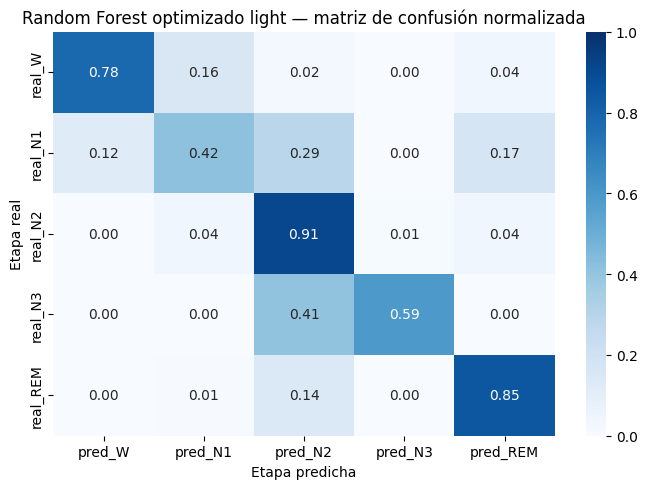


LightGBM optimizado light
accuracy    0.7885
kappa       0.7115
f1_macro    0.7541

Métricas por estadio:
     precision  recall  f1-score  support
W       0.8726  0.7847    0.8263   1161.0
N1      0.4808  0.5081    0.4941    862.0
N2      0.7588  0.8798    0.8148   3868.0
N3      0.9480  0.6688    0.7843   2207.0
REM     0.8287  0.8744    0.8509   1831.0


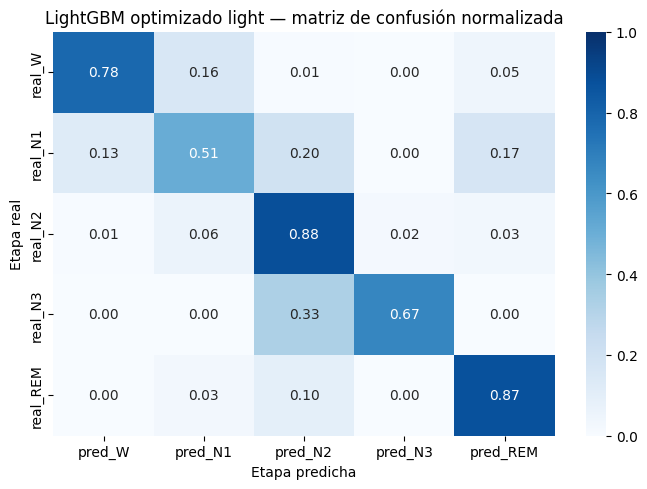

In [14]:
print('MEJOR RANDOM FOREST')
print(rf_search.best_parameters)
print('\nMEJOR LIGHTGBM')
print(lgbm_search.best_parameters)

display(compare_evaluations(
    rf_search.validation_evaluation,
    lgbm_search.validation_evaluation,
).round(4))
display_evaluation(rf_search.validation_evaluation)
display_evaluation(lgbm_search.validation_evaluation)